In [1221]:
from pathlib import Path

folder = Path("D:/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

for i, file in enumerate(files):
    print(f"[{i}] {file.stem}")

[0] 1
[1] 10
[2] 11
[3] 12
[4] 13
[5] 14
[6] 15
[7] 16
[8] 17
[9] 18
[10] 19
[11] 2
[12] 20
[13] 21
[14] 3
[15] 4
[16] 5
[17] 6
[18] 7
[19] 8
[20] 9


In [1222]:
IDX = 6

In [1223]:
import cv2
import numpy as np


def imread_unicode(path: str | Path, flags: int = cv2.IMREAD_COLOR_BGR) -> np.ndarray:
    """cv2.imread, переживающий кириллицу в пути (Windows/CP1251)."""
    buf = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(buf, flags)
    if img is None:
        raise ValueError(f"не удалось декодировать: {path}")
    return img

src = imread_unicode(files[IDX])
assert src is not None, f"Failed to read image: {files[IDX]}"

In [1224]:
from skimage.morphology import skeletonize

# Разрешение в датасете гуляет впятеро (1085x518 ... 6819x3378), а вся морфология
# работает в пикселях. Приводим чертёж к канонической толщине штриха СРАЗУ после
# загрузки — тогда весь пайплайн ниже живёт в одном масштабе, и радиусы ядер
# становятся константами на весь датасет.

TARGET_R = 4          # куда ставим пик гранулометрии = половина доминирующей толщины
R = TARGET_R * 2      # рабочий радиус открытия: сразу за популяцией линий


def _resize(bgr, s):
    return cv2.resize(bgr, None, fx=s, fy=s,
                      interpolation=cv2.INTER_CUBIC if s > 1 else cv2.INTER_AREA)


def _rough_bin(bgr):
    """Грубый бинарь только для оценки масштаба: важно отношение площади к длине."""
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return (cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1] > 0).astype(np.uint8)


def peak_r(bgr, s=1.0, rmax=12):
    """Радиус, на котором умирает основная масса линий."""
    b = _rough_bin(_resize(bgr, s)) if s != 1.0 else _rough_bin(bgr)
    a = np.array([int(b.sum()) if r == 0 else
                  int(cv2.morphologyEx(b, cv2.MORPH_OPEN,
                      cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))).sum())
                  for r in range(rmax)], float)
    return int(np.argmax(-np.diff(a))) + 1


def canon_scale(bgr):
    """Два прохода: грубо по средней толщине, точно по пику гранулометрии."""
    b = _rough_bin(bgr)
    s = (2 * TARGET_R) / max(b.sum() / max(skeletonize(b > 0).sum(), 1), 1e-6)
    return s * TARGET_R / peak_r(bgr, s)


src_raw = src                    # оригинал: координаты результата делим на sc
sc = canon_scale(src_raw)
src = _resize(src_raw, sc)

print(f"масштаб={sc:.3f}  {src_raw.shape[1]}x{src_raw.shape[0]} -> {src.shape[1]}x{src.shape[0]}")
print(f"пик после нормализации={peak_r(src)} (цель {TARGET_R}),  R={R}, ядро={2 * R + 1}")


масштаб=4.747  1475x919 -> 7002x4362
пик после нормализации=4 (цель 4),  R=8, ядро=17


In [1225]:
import numpy as np

# https://raw.githubusercontent.com/PaddlePaddle/PaddleOCR/main/ppocr/data/imaug/operators.py


def preprocess_detector(src_bgr: np.ndarray, limit_size: int = 2400) -> tuple[np.ndarray, float, float]:
    h, w = src_bgr.shape[:2]
    ratio = float(limit_size) / max(h, w)

    mean = np.array([0.485, 0.456, 0.406], np.float32).reshape(1, 1, 3)
    std = np.array([0.229, 0.224, 0.225], np.float32).reshape(1, 1, 3)

    resize_h, resize_w = int(h * ratio), int(w * ratio)
    # кратность 32
    # на 'Compute output and sum shape must match'
    resize_h = max(int(round(resize_h / 32) * 32), 32)
    resize_w = max(int(round(resize_w / 32) * 32), 32)

    interp = cv2.INTER_AREA if ratio < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(src_bgr, (resize_w, resize_h), interpolation=interp)

    blob = ((resized.astype(np.float32) / 255.0 - mean) / std).transpose(2, 0, 1)[np.newaxis]
    return blob


In [1226]:
import onnxruntime as ort

det_model_path = "./models/PP-OCRv5_server_det_infer.onnx"
det_session = ort.InferenceSession(det_model_path)

In [1227]:
scales = [380, 680, 980, 2400]
h, w = src.shape[:2]

acc = np.zeros((h, w), np.float32)
for s in scales:
    p = det_session.run(None, {"x": preprocess_detector(src, s)})[0][0, 0]
    acc += cv2.resize(p, (w, h), interpolation=cv2.INTER_LINEAR)
acc /= len(scales)


In [1228]:
mask = acc > 0.4

In [1229]:
from matplotlib import pyplot as plt

# plt.figure(figsize=(18, 11))
# plt.imshow(acc, cmap="viridis")
# plt.colorbar()


In [1230]:
ov = src.copy()
ov[mask] = (0, 0, 255)
blend = cv2.addWeighted(ov, 0.45, src, 0.55, 0)

# plt.figure(figsize=(18, 11))
# plt.imshow(blend[:, :, ::-1])
# plt.axis("off")


In [1231]:
n, lbl, st, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)

areas = st[1:, cv2.CC_STAT_AREA]
print(f"n={n - 1} a_med={np.median(areas):.1f}")
keep = areas > np.median(areas) * 0.2
mask_f = np.concatenate([[False], keep])[lbl]

print(f"n={n - 1} median area={(np.median(areas) * 0.1):.1f} keep={keep.sum()}")

n=42 a_med=16820.5
n=42 median area=1682.1 keep=41


In [1232]:
ov_f = src.copy()
ov_f[mask_f] = (0, 0, 255)
blend_f = cv2.addWeighted(ov_f, 0.45, src, 0.55, 0)

# plt.figure(figsize=(18, 11))
# plt.imshow(blend_f[:, :, ::-1])
# plt.axis("off")
# plt.title(f"n={n - 1}  a_med={np.median(areas):.1f}  keep={keep.sum()}")


маска: было=776449 стало=2179565 (2.81×)


Text(0.5, 1.0, 'тёмное — сердечник, светлое — прирост от unclip')

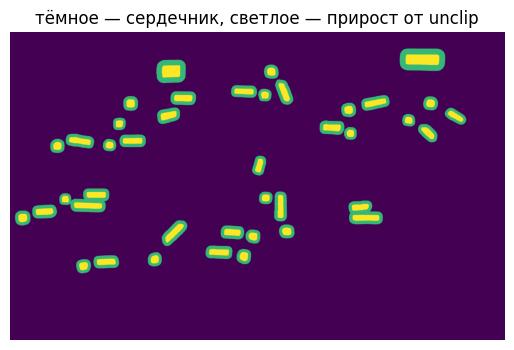

In [1233]:
UNCLIP = 1.5   # det_db_unclip_ratio

cnts, _ = cv2.findContours(mask_f.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_u = np.zeros(mask_f.shape, np.uint8)
for c in cnts:
    A, L = cv2.contourArea(c), cv2.arcLength(c, True)
    if L == 0:
        continue
    D = int(round(A * UNCLIP / L))
    cv2.drawContours(mask_u, [c], -1, 1, cv2.FILLED)
    if D > 0:
        cv2.drawContours(mask_u, [c], -1, 1, 2 * D + 1)   # обводка толщиной 2D = смещение края на D
mask_u = mask_u > 0

print(f"маска: было={mask_f.sum()} стало={mask_u.sum()} ({mask_u.sum() / mask_f.sum():.2f}×)")
plt.figure(figsize=(14, 4))
plt.imshow(np.where(mask_u, 2, 0) + mask_f, cmap="viridis"); plt.axis("off")
plt.title("тёмное — сердечник, светлое — прирост от unclip")



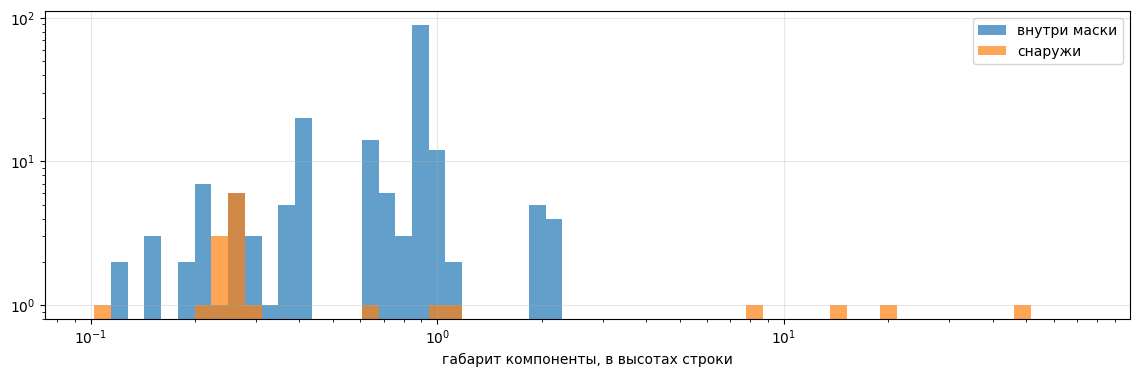

In [1234]:
from skimage.filters import apply_hysteresis_threshold

cnts, _ = cv2.findContours(mask_f.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
h_txt = np.median([min(cv2.minAreaRect(c)[1]) for c in cnts])

# фон на уменьшенной копии: ядро всегда ~8px независимо от масштаба чертежа
g0 = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
s = max(1, int(h_txt // 8))
small = cv2.resize(g0, None, fx=1 / s, fy=1 / s, interpolation=cv2.INTER_AREA) if s > 1 else g0
k = int(h_txt / s) | 1
bg_s = cv2.morphologyEx(small, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k)))
bg = cv2.resize(bg_s, (g0.shape[1], g0.shape[0]), cv2.INTER_LINEAR) if s > 1 else bg_s



d = np.clip((bg.astype(np.float32) - g0) / np.maximum(bg, 1), 0, 1)
ink_all = apply_hysteresis_threshold(d, 0.35, 0.5)

n, lbl, st, _ = cv2.connectedComponentsWithStats(ink_all.astype(np.uint8), 8)
area = st[:, cv2.CC_STAT_AREA]
frac = np.bincount(lbl[mask_f], minlength=n) / np.maximum(area, 1)
ext = np.maximum(st[:, cv2.CC_STAT_WIDTH], st[:, cv2.CC_STAT_HEIGHT]) / h_txt
inside = np.bincount(lbl[mask_u], minlength=n) / np.maximum(area, 1)

is_txt = frac > 0.1
is_txt[0] = False
# ink0 = ink_all & ~is_txt[lbl] & ~mask_f

plt.figure(figsize=(14, 4))
b = np.logspace(np.log10(max(ext[1:].min(), 0.05)), np.log10(ext[1:].max()), 60)
plt.hist(ext[1:][inside[1:] > 0.5], bins=b, alpha=0.7, label="внутри маски")
plt.hist(ext[1:][inside[1:] <= 0.5], bins=b, alpha=0.7, label="снаружи")
plt.xscale("log"); plt.yscale("log"); plt.xlabel("габарит компоненты, в высотах строки")
plt.legend(); plt.grid(alpha=0.3)


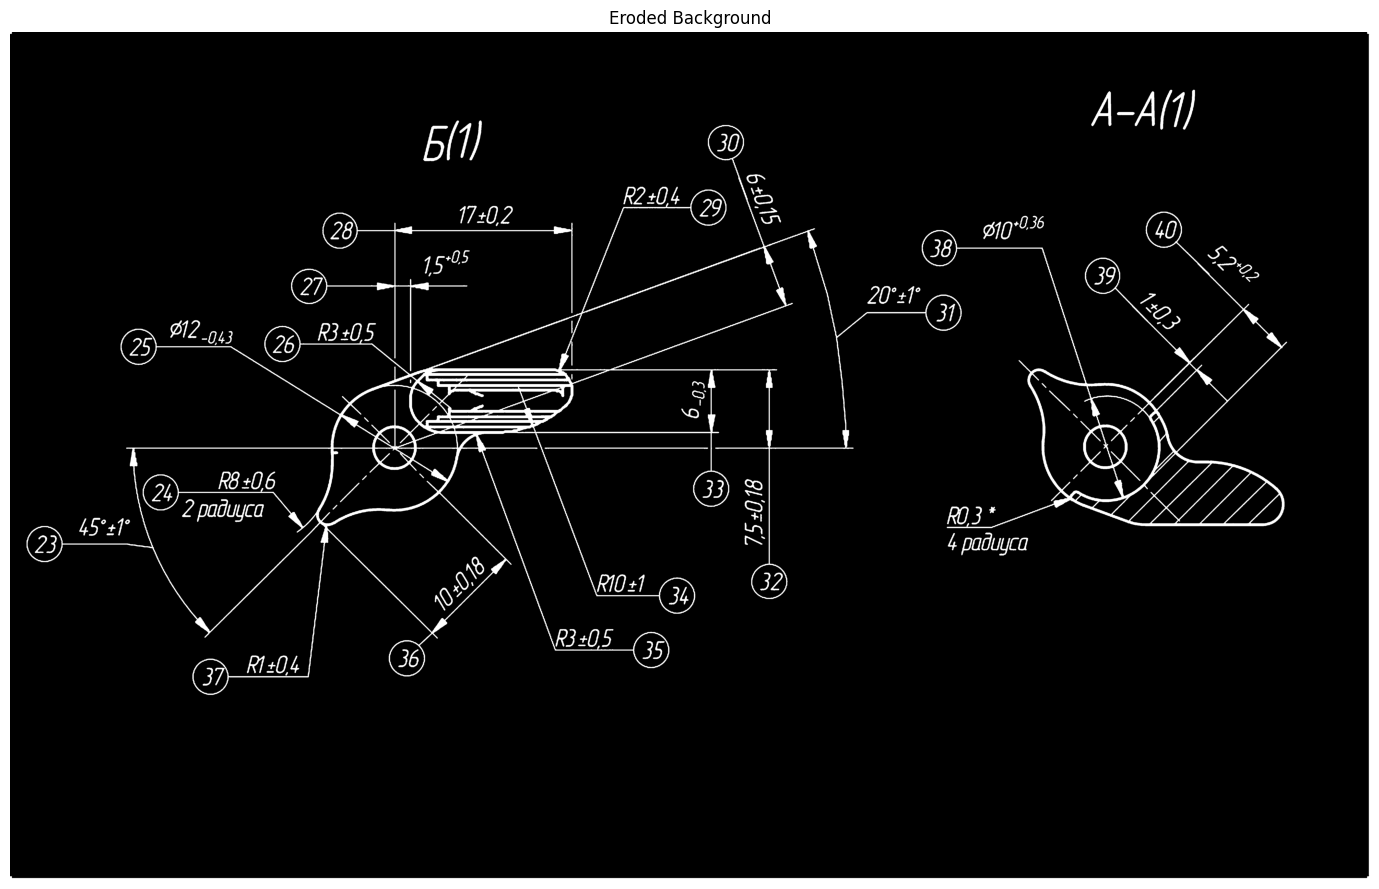

In [1235]:
plt.figure(figsize=(18, 11))
plt.imshow(ink_all, cmap="gray")
plt.axis("off")
plt.title("Eroded Background")
plt.show()

In [1236]:
for S in [1.0, 1.5, 2.0, 3.0, 4.0, 6.0]:
    m = (ext < S) & (inside > 0.1); m[0] = False
    print(f"S={S:4.1f}  компонент={m.sum():4d}  краски={area[m].sum() / area[1:].sum():6.2%}")



S= 1.0  компонент= 171  краски=20.71%
S= 1.5  компонент= 176  краски=21.81%
S= 2.0  компонент= 181  краски=24.57%
S= 3.0  компонент= 185  краски=25.91%
S= 4.0  компонент= 185  краски=25.91%
S= 6.0  компонент= 185  краски=25.91%


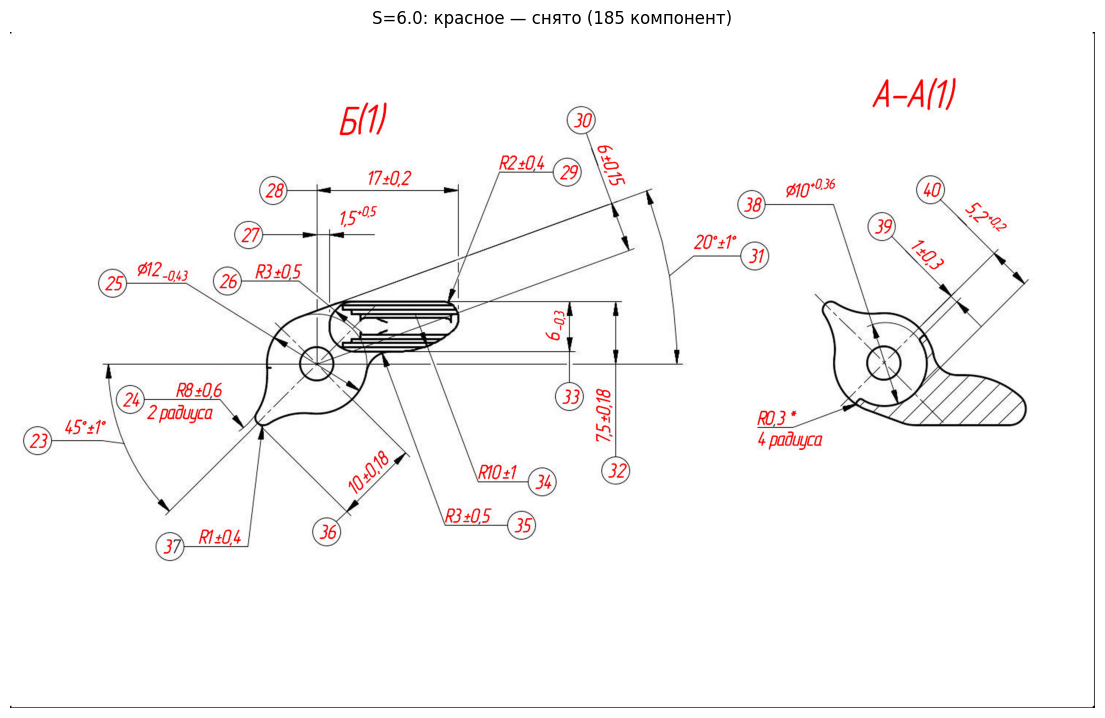

In [1237]:
S = 6.0
is_txt = (ext < S) & (inside > 0.1)
is_txt[0] = False

vis = src.copy()
vis[is_txt[lbl] & ink_all] = (0, 0, 255)

plt.figure(figsize=(14, 10))
plt.imshow(vis[:, :, ::-1])
plt.axis("off")
plt.title(f"S={S}: красное — снято ({is_txt.sum()} компонент)")
plt.show()


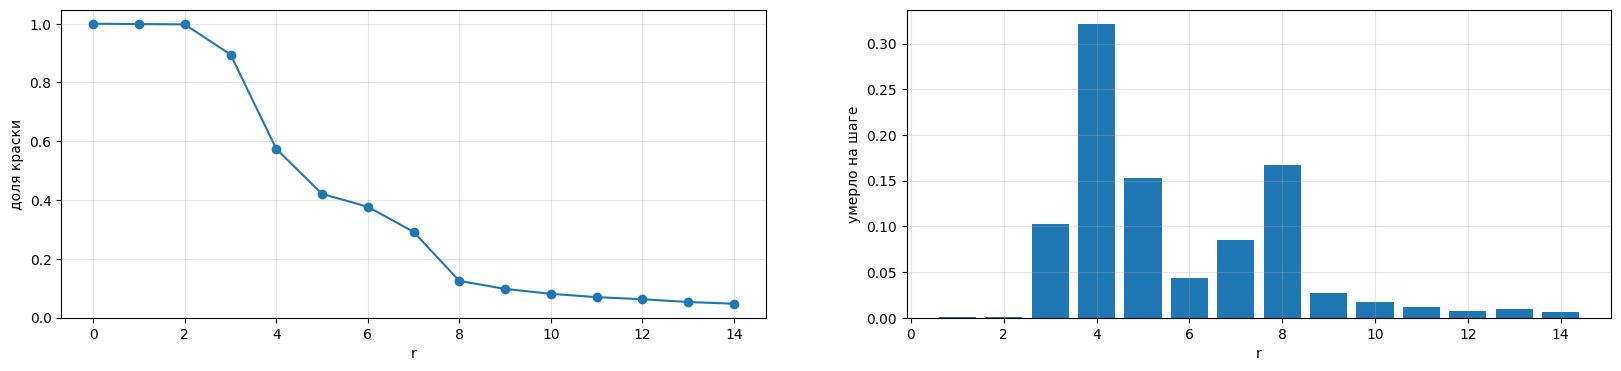

In [1238]:
rs = range(0, 15)
areas = []
for r in rs:
    if r == 0:
        b = ink_all.astype(np.uint8)
    else:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
        b = cv2.morphologyEx(ink_all.astype(np.uint8), cv2.MORPH_OPEN, k)
    areas.append(int(b.sum()))

areas = np.array(areas, float)
spec = -np.diff(areas)                      # сколько краски умирает на каждом шаге

fig, ax = plt.subplots(1, 2, figsize=(20, 4))
ax[0].plot(list(rs), areas / areas[0], "o-"); ax[0].set_xlabel("r"); ax[0].set_ylabel("доля краски")
ax[1].bar(list(rs)[1:], spec / areas[0]);    ax[1].set_xlabel("r"); ax[1].set_ylabel("умерло на шаге")
for a in ax:
    a.grid(alpha=0.3)


In [1239]:
# R задан константой при нормализации. Здесь сверка: мода спектра по рабочей краске
# должна стоять на TARGET_R. Хвост справа от моды — это разброс толщин и наконечники,
# он законен и на выбор R не влияет.
peak_ink = int(np.argmax(spec)) + 1
print(f"мода спектра={peak_ink} (цель {TARGET_R})  |  R={R}, ядро {2 * R + 1}, "
      f"выживает {areas[R] / areas[0]:.1%}")
if abs(peak_ink - TARGET_R) > 1:
    print("ВНИМАНИЕ: мода уехала от цели — масштаб не нормализовался, проверь canon_scale")


мода спектра=4 (цель 4)  |  R=8, ядро 17, выживает 12.5%


Text(0.5, 1.0, 'зелёные — уцелели (149), красные — съедены очисткой текста (29)')

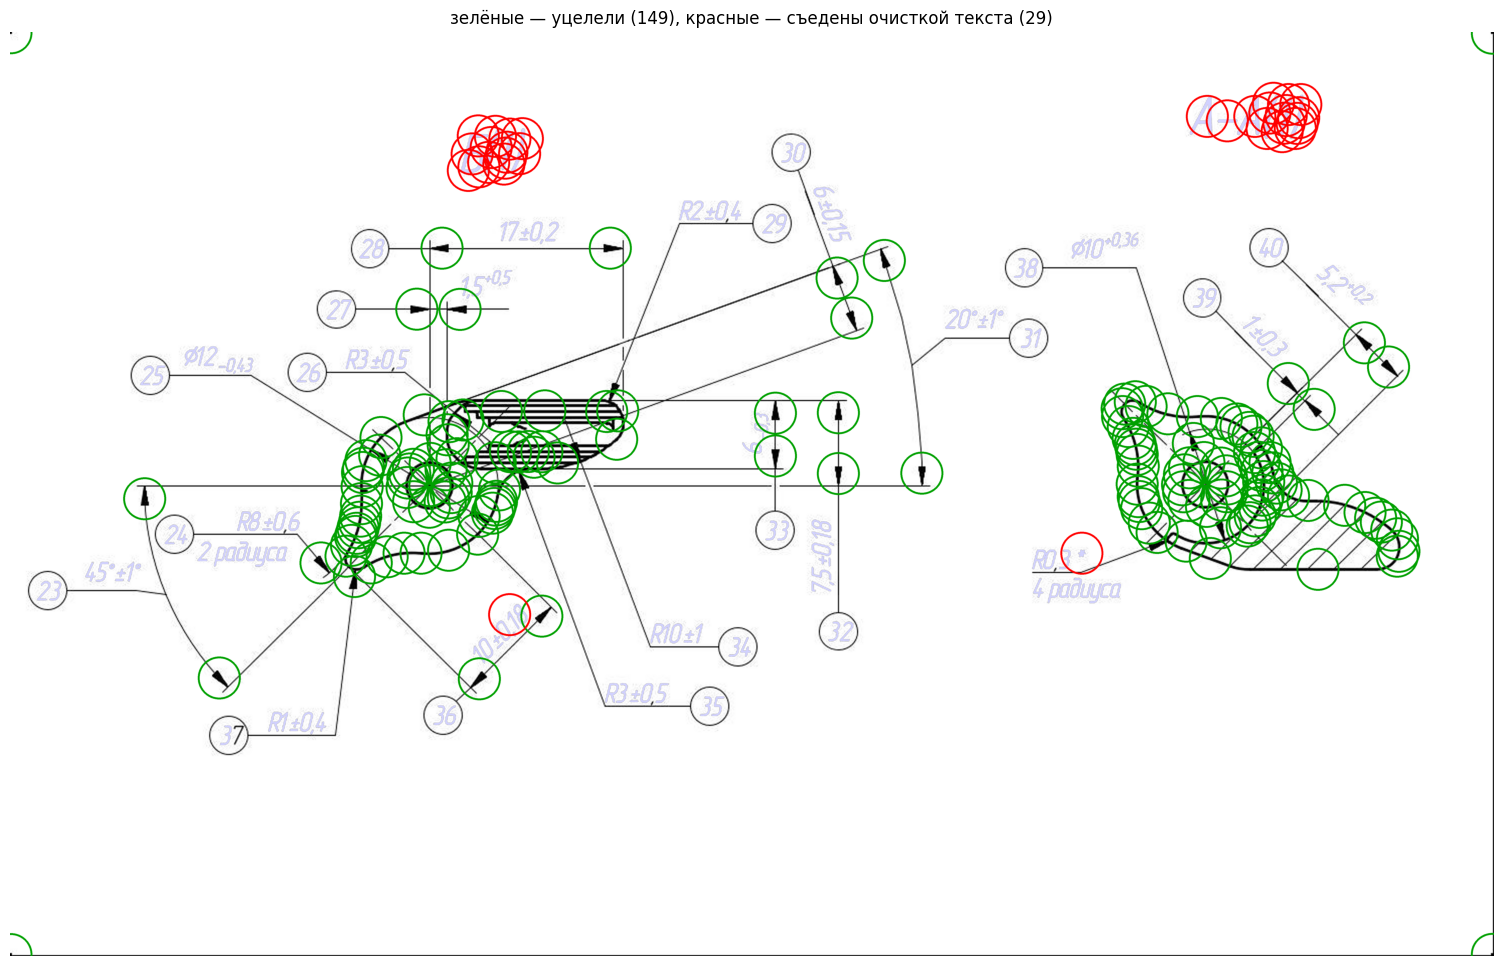

In [1240]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * R - 1, 2 * R - 1))
sA = cv2.morphologyEx(ink_all.astype(np.uint8), cv2.MORPH_OPEN, kernel)

txt = is_txt[lbl] & ink_all
ink = ink_all & ~txt

nA, lA, stA, cA = cv2.connectedComponentsWithStats(sA.astype(np.uint8), 8)
alive = np.bincount(lA[ink], minlength=nA) > 0       # хоть один пиксель пятна остался в ink

vis = src.copy()
vis[txt] = (255, 210, 210)                            # бледным — что сняли как текст
for i in range(1, nA):
    x, y = cA[i].astype(int)
    c = (0, 160, 0) if alive[i] else (0, 0, 255)
    cv2.circle(vis, (x, y), int(h_txt), c, max(2, int(h_txt / 12)))

plt.figure(figsize=(22, 12)); plt.imshow(vis[:, :, ::-1]); plt.axis("off")
plt.title(f"зелёные — уцелели ({alive[1:].sum()}), красные — съедены очисткой текста ({(~alive[1:]).sum()})")

пятен=121  доля треугольника: 0.46…0.80


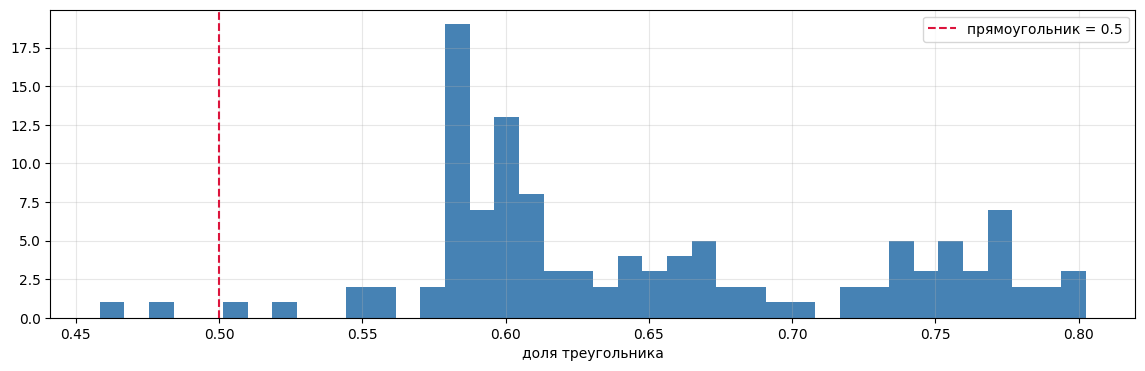

In [1241]:
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * R + 1, 2 * R + 1))
blobs = cv2.morphologyEx(ink.astype(np.uint8), cv2.MORPH_OPEN, k)

rec = []                                   # (контур, доля треугольника, треугольник, центр)
for c in cv2.findContours(blobs, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
    A = cv2.contourArea(c)
    M = cv2.moments(c)
    if A < 3 or M["m00"] == 0:
        continue
    at, T = cv2.minEnclosingTriangle(c)
    if T is None or at <= 0:
        continue
    rec.append((c, A / at, T.reshape(3, 2), (M["m10"] / M["m00"], M["m01"] / M["m00"])))

score = np.array([r[1] for r in rec])
print(f"пятен={len(rec)}  доля треугольника: {score.min():.2f}…{score.max():.2f}")

plt.figure(figsize=(14, 4))
plt.hist(score, bins=40, color="steelblue")
plt.axvline(0.5, color="crimson", ls="--", label="прямоугольник = 0.5")
plt.xlabel("доля треугольника"); plt.legend(); plt.grid(alpha=0.3)


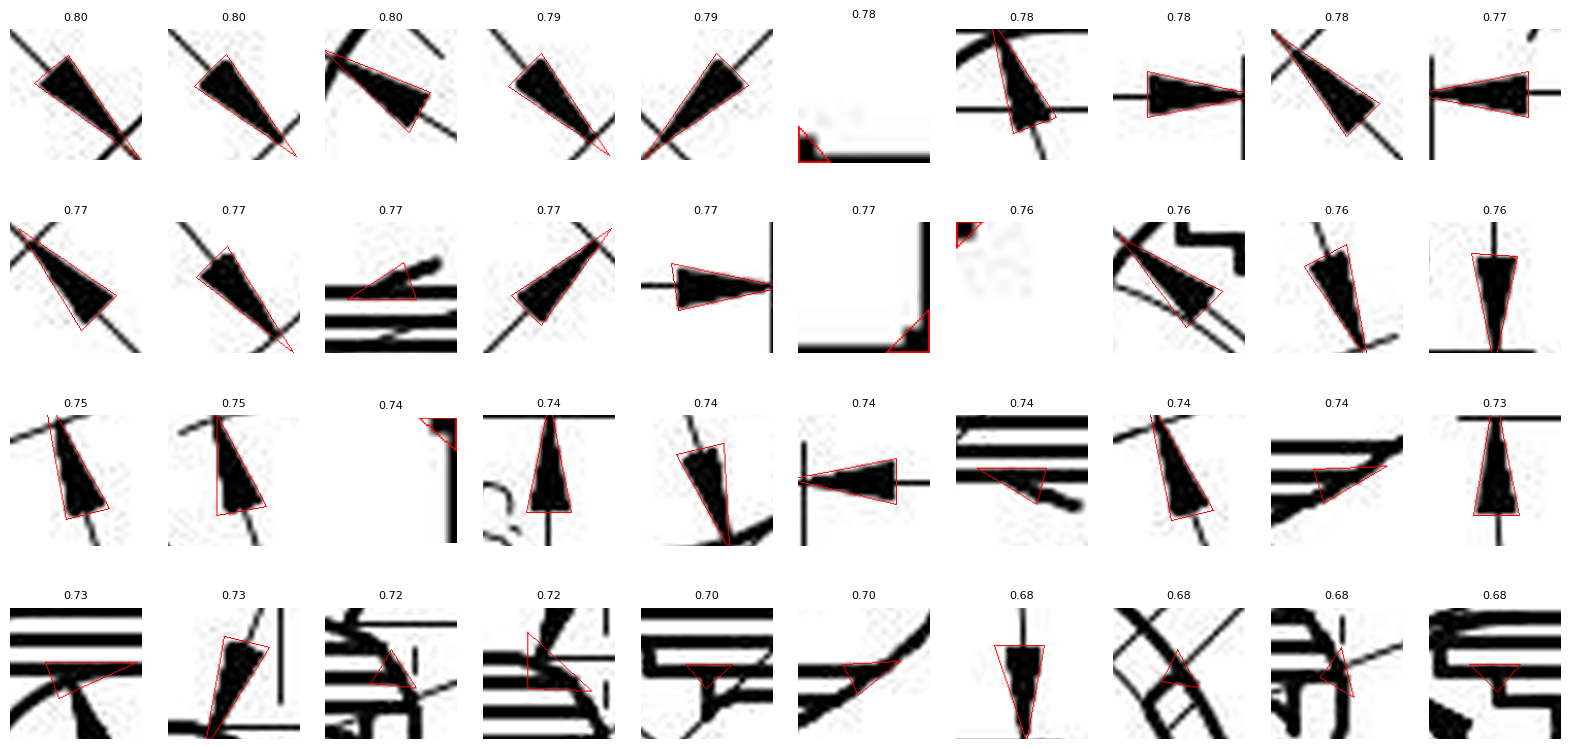

In [1242]:
idx = np.argsort(-score)[:40]
p = int(8 * R)
cols = 10
rows = int(np.ceil(len(idx) / cols))
fig, ax = plt.subplots(rows, cols, figsize=(20, 2.4 * rows))
for a, i in zip(ax.ravel(), idx):
    x, y = map(int, rec[i][3])
    x0, y0 = max(0, x - p), max(0, y - p)
    patch = src[y0:y + p, x0:x + p].copy()
    cv2.polylines(patch, [(rec[i][2] - [x0, y0]).astype(np.int32)], True, (0, 0, 255), 1)
    a.imshow(patch[:, :, ::-1])
    a.set_title(f"{score[i]:.2f}", fontsize=8)
for a in ax.ravel():
    a.axis("off")
